### Import languages and data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../MLS DATA.csv')
df.columns = ['Rk'] + list(df.columns[:-1])
df.set_index('Rk', inplace=True)
df.index.name = None
df.columns = df.columns.str.lower()

---

### Display first and last 5 rows

In [ ]:
df.head()


In [ ]:
df.tail()

### Analysis:
- 23 variables
- 882 rows

---

# Phase 1

## Baseline Flitering & Exploratory Data

- Filter players who have at least 450 minutes of playing time and filter players to be less than or equal to 24 years old
- Filter non penalty goals per 90 min

In [ ]:
df = pd.read_csv('../MLS DATA.csv')

df_clean['min'] = pd.to_numeric(df_clean['min'].astype(str).str.replace(',', ''), errors='coerce')
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

# 2. create npg_per_90 column (non-penalty goals per 90)
df_clean['npg_per_90'] = df_clean['g-pk'] / df_clean['90s']

# 3. filter for players who meet the minutes (at least 450) and age (u24) criteria
df_target = df_clean[(df_clean['min'] >= 450) & (df_clean['age'] <= 24)].copy()

# Updated to match the columns you just created
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='min', y='npg_per_90', data=df_target)
plt.xlabel('total minutes played')
plt.ylabel('non-penalty goals per 90')
plt.title('identifying undervalued young talent (u24)')
plt.grid(True, linestyle='--', alpha=0.6) 
plt.show()

In [ ]:
# 1. clean the position column to only show the primary position
# this slices the string to keep only the first two letters (e.g., turns 'mf,fw' into 'mf')
df_target['pos'] = df_target['pos'].astype(str).str[:2].str.lower()

# 2. set the size of the plot
plt.figure(figsize=(10, 6))

# 3. plot the data with our newly cleaned 'pos' column
sns.scatterplot(x='min', y='npg_per_90', hue='pos', data=df_target, s=75, palette='bright')

# 4. labels, title, legend, and grid
plt.xlabel('total minutes played')
plt.ylabel('non-penalty goals per 90')
plt.title('identifying undervalued young talent by primary position (u24)')
plt.legend(title='position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(visible=1, linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. display the plot
plt.show()

### Analysis:

- Dependent Variable: Non-Penalty Goals per 90
- Independent Variables: name, squad, position, age, minutes

- Clean the table to only have the needed variables. 

In [ ]:
# 1. Safely recreate the npg_per_90 column
# Converting to numeric first prevents any division errors if the data loaded as text
df_clean['g-pk'] = pd.to_numeric(df_clean['g-pk'], errors='coerce')
df_clean['90s'] = pd.to_numeric(df_clean['90s'], errors='coerce')
df_clean['npg_per_90'] = df_clean['g-pk'] / df_clean['90s']

# 2. Define the exact columns we want to keep
columns_to_keep = [
    'player',
    'squad',
    'pos',
    'age',
    'min',
    'npg_per_90'
]

# 3. Apply the filters (U24, 450+ mins) AND slice the columns at the same time
df_target = df_clean[(df_clean['min'] >= 450) & (df_clean['age'] <= 24)][columns_to_keep].copy()

# 4. Check the results
print(df_target.head())

In [ ]:
# sort the dataframe by the dependent variable in descending order
top_prospects = df_target.sort_values(by='npg_per_90', ascending=0)

# display the top 5 players to identify the outlier and the runners-up
print(top_prospects.head())

### Analysis
- the model works right now in terms of young players and non penalty goals

---

# Phase 2

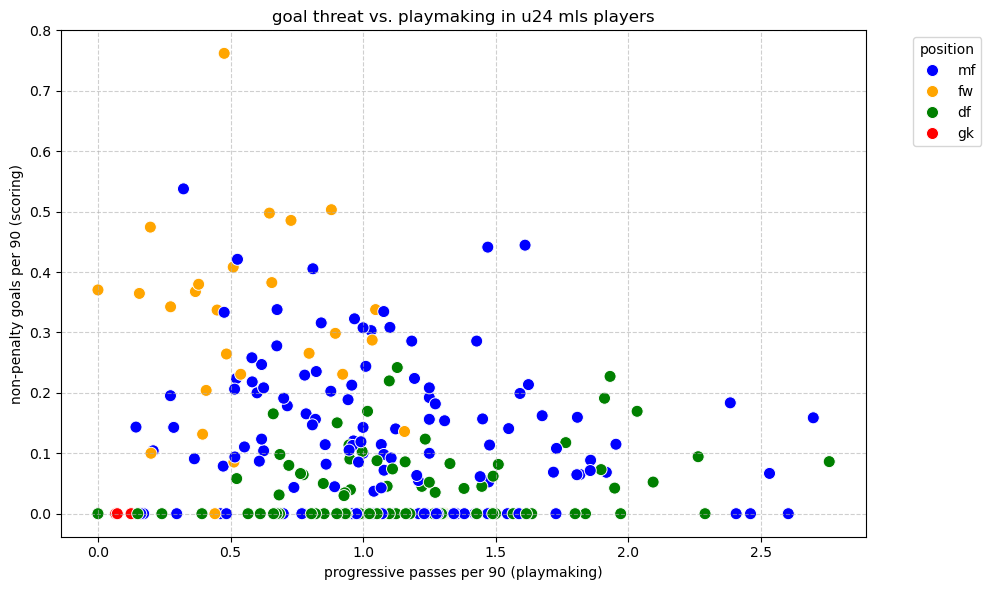

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. load phase 1 and grab core columns including 'pos'
df_phase1 = pd.read_csv('../mls data.csv')
df_phase1.columns = ['rk'] + list(df_phase1.columns[:-1])
df_phase1.columns = df_phase1.columns.str.lower().str.strip()
df1_subset = df_phase1[['player', 'min', '90s', 'age', 'g-pk', 'pos']].copy()

# 2. load phase 2 and grab player + progressive passes
df_phase2 = pd.read_excel('../mls data cont.xlsx')
df_phase2.columns = df_phase2.columns.str.lower().str.strip()
playmaking_col = df_phase2.columns[-1] 
df2_subset = df_phase2[['player', playmaking_col]].copy()
df2_subset.columns = ['player', 'prgp_clean'] 

# 3. clean player names and extract primary position
df1_subset['player'] = df1_subset['player'].astype(str).str.strip()
df2_subset['player'] = df2_subset['player'].astype(str).str.strip()
df1_subset['pos'] = df1_subset['pos'].astype(str).str[:2].str.lower()

# 4. merge our clean subsets
df_target = pd.merge(df1_subset, df2_subset, on='player', how='inner')

# 5. fix data types so python can do math
df_target['min'] = pd.to_numeric(df_target['min'].astype(str).str.replace(',', ''), errors='coerce')
df_target['90s'] = pd.to_numeric(df_target['90s'], errors='coerce')
df_target['g-pk'] = pd.to_numeric(df_target['g-pk'], errors='coerce')
df_target['prgp_clean'] = pd.to_numeric(df_target['prgp_clean'], errors='coerce')

# 6. apply your baseline filters
df_target = df_target[(df_target['min'] >= 450) & (df_target['age'] <= 24)].copy()

# 7. create 'per 90' metrics
df_target['npg_per_90'] = df_target['g-pk'] / df_target['90s']
df_target['prgp_per_90'] = df_target['prgp_clean'] / df_target['90s']

# 8. setup colors: defense/midfield = red, forward = blue, any gk = gray
pos_colors = {'df': 'green', 'mf': 'blue', 'fw': 'orange', 'gk': 'red'}

# 9. plot the double threat analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='prgp_per_90', 
    y='npg_per_90', 
    hue='pos', 
    palette=pos_colors, 
    data=df_target, 
    s=75
)

plt.xlabel('progressive passes per 90 (playmaking)')
plt.ylabel('non-penalty goals per 90 (scoring)')
plt.title('goal threat vs. playmaking in u24 mls players')
plt.grid(visible=1, linestyle='--', alpha=0.6)
plt.legend(title='position', bbox_to_anchor=(1.05, 1), loc='upper left')

# 10. add player names to the top right quadrant
for i in range(df_target.shape[0]):
    if df_target['npg_per_90'].iloc[i] > 0.3 and df_target['prgp_per_90'].iloc[i] > 3.0:
        plt.text(
            df_target['prgp_per_90'].iloc[i] + 0.1, 
            df_target['npg_per_90'].iloc[i], 
            df_target['player'].iloc[i].lower(), 
            fontsize=9
        )

plt.tight_layout()
plt.savefig('red_bulls_targets.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# create a combined threat score to rank players by both metrics
df_target['threat_score'] = df_target['npg_per_90'] + df_target['prgp_per_90']

# sort the dataframe by the highest threat score and grab the top 50
top_50_targets = df_target.sort_values(by='threat_score', ascending=0).head(50)

# print only the final sorted list
print("top 50 recommended transfer targets:")
print(top_50_targets[['player', 'age', 'pos', 'npg_per_90', 'prgp_per_90', 'threat_score']].reset_index(drop=1))

top 50 recommended transfer targets:
                    player  age pos  npg_per_90  prgp_per_90  threat_score
0            Taha Habroune   18  mf    0.158730     2.698413      2.857143
1         Leonardo Barroso   19  df    0.086207     2.758621      2.844828
2            Ronald Donkor   20  mf    0.000000     2.604167      2.604167
3           Yannick Bright   23  mf    0.066667     2.533333      2.600000
4           Lucas Sanabria   21  mf    0.183486     2.385321      2.568807
5        Matthew Longstaff   24  mf    0.000000     2.461538      2.461538
6   Alejandro Alvarado Jr.   21  mf    0.000000     2.407407      2.407407
7               Jalen Neal   21  df    0.094340     2.264151      2.358491
8          Gilberto Flores   21  df    0.000000     2.290076      2.290076
9             Carlos Terán   24  df    0.169492     2.033898      2.203390
10         Mauricio Cuevas   21  df    0.227273     1.931818      2.159091
11           Carlos Garcés   23  df    0.052356     2.094241   

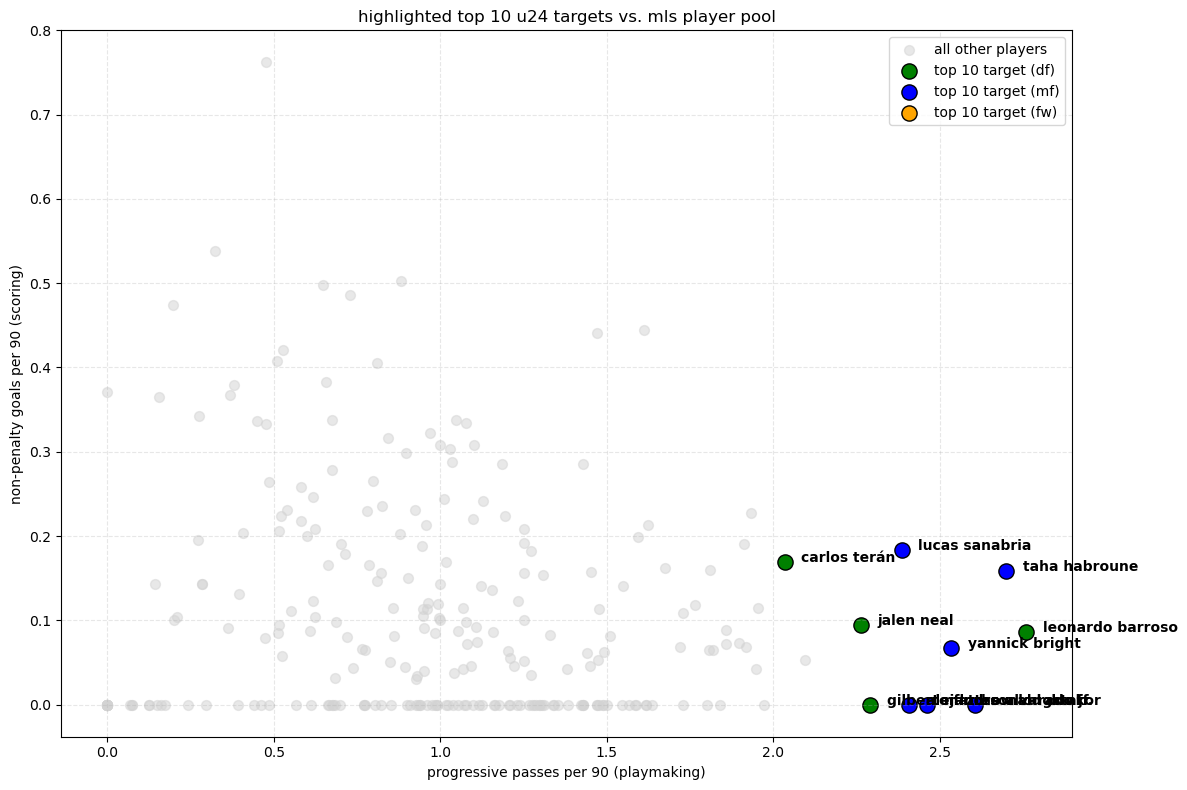

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. create the combined threat score and find the top 10
df_target['threat_score'] = df_target['npg_per_90'] + df_target['prgp_per_90']
top_10 = df_target.sort_values(by='threat_score', ascending=0).head(10)

# 2. setup the figure
plt.figure(figsize=(12, 8))

# 3. plot ALL players first in a light gray so they stay in the background
plt.scatter(
    df_target['prgp_per_90'], 
    df_target['npg_per_90'], 
    color='lightgray', 
    alpha=0.5, 
    s=50, 
    label='all other players'
)

# 4. highlight only the top 10 using their position colors
color_map = {'df': 'green', 'mf': 'blue', 'fw': 'orange'}

for pos, color in color_map.items():
    pos_data = top_10[top_10['pos'] == pos]
    plt.scatter(
        pos_data['prgp_per_90'], 
        pos_data['npg_per_90'], 
        color=color, 
        edgecolor='black', 
        s=120, 
        label=f'top 10 target ({pos})'
    )

# 5. add labels only for the top 10 players
for i in range(top_10.shape[0]):
    plt.text(
        top_10['prgp_per_90'].iloc[i] + 0.05, 
        top_10['npg_per_90'].iloc[i], 
        top_10['player'].iloc[i].lower(), 
        fontsize=10, 
        fontweight='bold'
    )

# 6. final formatting
plt.xlabel('progressive passes per 90 (playmaking)')
plt.ylabel('non-penalty goals per 90 (scoring)')
plt.title('highlighted top 10 u24 targets vs. mls player pool')
plt.grid(visible=1, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()

# 7. save the high-res version for your slide
plt.savefig('highlighted_targets.png', dpi=300)
plt.show()